In [154]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from nltk.tokenize import word_tokenize
from collections import Counter
import nltk

In [155]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [156]:
with open("input.txt", "r", encoding="utf-8") as f:
    document = f.read()

In [157]:
##tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [158]:
tokens=word_tokenize(document.lower())
len(tokens)

34661

In [159]:
vocab={'<unk>':0}

In [160]:
for token in Counter(tokens).keys():
  if token not in vocab:
    vocab[token]=len(vocab)

len(vocab)


3022

In [161]:
input_sentence=document.split('\n')

In [162]:
def text_to_indices(sentence,vocab):
  numerical_sentence=[]
  for token in sentence:
    if token in vocab:
      numerical_sentence.append(vocab[token])
    else:
        numerical_sentence.append(vocab['<unk>'])
  return numerical_sentence

In [163]:
input_numerical_sentence=[]
for sentence in input_sentence:
  tokens=word_tokenize(sentence.lower())
  indices=text_to_indices(tokens,vocab)
  input_numerical_sentence.append(indices)


In [164]:
train_seq=[]
for sentence in input_numerical_sentence:
  for i in range(1,len(sentence)):
    train_seq.append(sentence[:i+1])

In [165]:
train_seq[0]

[1, 1]

In [166]:
len_list=[]
for s in train_seq:
  len_list.append(len(s))
max(len_list)

28

In [167]:
padded_train=[]
for s in train_seq:
 padded_train.append([0]*(max(len_list)-len(s))+s)

In [168]:
padded_train[0]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1]

In [169]:
padded_train=torch.tensor(padded_train,dtype=torch.long)

In [170]:
x=padded_train[:,:-1]
y=padded_train[:,-1]
x.shape

torch.Size([32337, 27])

In [171]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [172]:
class customDataset(Dataset):
  def __init__(self,x,y):
    self.x=x
    self.y=y
  def __len__(self):
    return self.x.shape[0]
  def __getitem__(self,index):
    return self.x[index],self.y[index]

In [173]:
train_dataset = customDataset(x_train, y_train)
test_dataset = customDataset(x_test, y_test)

In [174]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [175]:
class Lstm(nn.Module):
  def __init__(self,vocab_size):
    super().__init__()
    self.Embedings=nn.Embedding(vocab_size,100)
    self.lstm=nn.LSTM(100,128,batch_first=True)
    self.linear=nn.Linear(128,vocab_size)

  def forward(self,x):
    embedded=self.Embedings(x)
    intermediate_state,(final_hidded_state,final_cell_state)=self.lstm(embedded)
    output=self.linear(final_hidded_state.squeeze(0))
    return output

In [176]:
model=Lstm(len(vocab))

In [177]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [178]:
model.to(device)

Lstm(
  (Embedings): Embedding(3022, 100)
  (lstm): LSTM(100, 128, batch_first=True)
  (linear): Linear(in_features=128, out_features=3022, bias=True)
)

In [179]:
learning_rate=0.001
epochs=50
Loss=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [180]:
training_loss = []
model.train()
for epoch in range(epochs):
  total_loss=0
  for batch_x,batch_y in train_loader:
    batch_x,batch_y=batch_x.to(device),batch_y.to(device)

    optimizer.zero_grad()

    output=model(batch_x)

    loss=Loss(output,batch_y)

    loss.backward()

    optimizer.step()

    total_loss+=loss.item()

  avg_loss = total_loss / len(train_loader)
  training_loss.append(avg_loss)
  print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

Epoch 1/50, Loss: 5.4340
Epoch 2/50, Loss: 4.5325
Epoch 3/50, Loss: 4.0918
Epoch 4/50, Loss: 3.7404
Epoch 5/50, Loss: 3.4275
Epoch 6/50, Loss: 3.1429
Epoch 7/50, Loss: 2.8782
Epoch 8/50, Loss: 2.6308
Epoch 9/50, Loss: 2.4035
Epoch 10/50, Loss: 2.1923
Epoch 11/50, Loss: 2.0009
Epoch 12/50, Loss: 1.8273
Epoch 13/50, Loss: 1.6661
Epoch 14/50, Loss: 1.5207
Epoch 15/50, Loss: 1.3893
Epoch 16/50, Loss: 1.2699
Epoch 17/50, Loss: 1.1594
Epoch 18/50, Loss: 1.0621
Epoch 19/50, Loss: 0.9719
Epoch 20/50, Loss: 0.8932
Epoch 21/50, Loss: 0.8185
Epoch 22/50, Loss: 0.7573
Epoch 23/50, Loss: 0.6979
Epoch 24/50, Loss: 0.6498
Epoch 25/50, Loss: 0.6003
Epoch 26/50, Loss: 0.5611
Epoch 27/50, Loss: 0.5239
Epoch 28/50, Loss: 0.4932
Epoch 29/50, Loss: 0.4670
Epoch 30/50, Loss: 0.4418
Epoch 31/50, Loss: 0.4218
Epoch 32/50, Loss: 0.4008
Epoch 33/50, Loss: 0.3842
Epoch 34/50, Loss: 0.3747
Epoch 35/50, Loss: 0.3638
Epoch 36/50, Loss: 0.3551
Epoch 37/50, Loss: 0.3439
Epoch 38/50, Loss: 0.3316
Epoch 39/50, Loss: 0.

In [192]:
model.eval()

train_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        output = model(batch_x)

        loss = Loss(output, batch_y)
        train_loss += loss.item()

        _, predicted = torch.max(output, dim=1)

        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

print(f"Train Loss: {train_loss/len(train_loader):.4f}")
print(f"Train Accuracy: {(correct/total)*100:.2f}%")

Train Loss: 0.2433
Train Accuracy: 93.16%


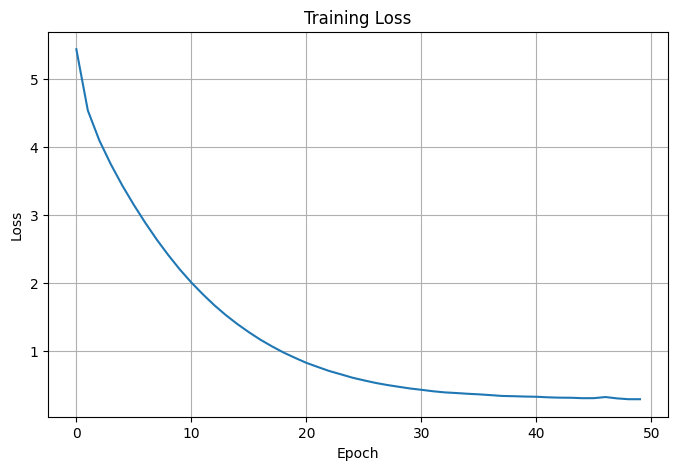

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(training_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [195]:
def prediction(model,vocab,text):
  tokenized_text=word_tokenize(text.lower())

  numerical=text_to_indices(tokenized_text,vocab)

  padding=torch.tensor([0]*(27-len(numerical))+numerical,dtype=torch.long).unsqueeze(0)
  padding=padding.to(device)

  output=model(padding)

  value,index=torch.max(output,dim=1)

  return text+" "+list(vocab.keys())[index]

In [196]:
num_tokens=12
input="Alice was beginning to"
for i in range(num_tokens):
  output=prediction(model,vocab,input)
  print(output)
  input=output



Alice was beginning to get
Alice was beginning to get very
Alice was beginning to get very tired
Alice was beginning to get very tired of
Alice was beginning to get very tired of sitting
Alice was beginning to get very tired of sitting by
Alice was beginning to get very tired of sitting by her
Alice was beginning to get very tired of sitting by her sister
Alice was beginning to get very tired of sitting by her sister on
Alice was beginning to get very tired of sitting by her sister on the
Alice was beginning to get very tired of sitting by her sister on the matter
Alice was beginning to get very tired of sitting by her sister on the matter .


In [197]:
torch.save(model.state_dict(), "lstm_model.pth")